In [1]:
from pathlib import Path
import platform

WSL_ROOT = Path("/mnt/c/Users/maorb/work/ship_positions")
WIN_ROOT = Path(r"C:\Users\maorb\work\ship_positions")

PROJECT_ROOT = WSL_ROOT if WSL_ROOT.exists() else WIN_ROOT
print("Kernel OS:", platform.system())
print("Project root resolved to:", PROJECT_ROOT)

%cd $PROJECT_ROOT
%pwd

Kernel OS: Windows
Project root resolved to: C:\Users\maorb\work\ship_positions
C:\Users\maorb\work\ship_positions


'C:\\Users\\maorb\\work\\ship_positions'

In [12]:
import duckdb

target_db = PROJECT_ROOT / "data" / "silver" / "ship_positions.db"
raw_full_db = PROJECT_ROOT / "data" / "raw" / "ship_positions.db"
raw_incremental_db = PROJECT_ROOT / "data" / "raw" / "ship_positions_incremental.db"

with duckdb.connect(str(target_db)) as con_target:
    sample_target = con_target.execute(
        """
        SELECT
            ship_name, time_ts, lat, lon, sog, cog, rot, acceleration, distance_traveled, elt_published_at
        FROM silver.SHIP_POSITIONS
        USING SAMPLE 50000
        """
    ).df()

    sample_rejects = con_target.execute(
        """
        SELECT
            ship_name, raw_time, lat, lon, sog, cog, dq_reason, elt_rejected_at
        FROM silver.SHIP_POSITIONS_REJECTS
        USING SAMPLE 50000
        """
    ).df()

with duckdb.connect(str(raw_full_db)) as con_raw:
    sample_raw = con_raw.execute(
        """
        SELECT ship_name, time, lat, lon, sog, cog
        FROM raw.ship_positions
        USING SAMPLE 50000
        """
    ).df()

with duckdb.connect(str(raw_incremental_db)) as con_incr:
    sample_incremental = con_incr.execute(
        """
        SELECT ship_name, time, lat, lon, sog, cog
        FROM raw.ship_positions
        USING SAMPLE 50000
        """
    ).df()

print("Sample rows from silver.SHIP_POSITIONS")
display(sample_target)

print("Sample rows from silver.SHIP_POSITIONS_REJECTS")
display(sample_rejects)

print("Sample rows from raw.ship_positions (full source DB)")
display(sample_raw)

print("Sample rows from raw.ship_positions_incremental (incremental source DB)")
display(sample_incremental)

Sample rows from silver.SHIP_POSITIONS


,ship_name,time_ts,lat,lon,sog,cog,rot,acceleration,distance_traveled,elt_published_at
0,Ship_B,2026-02-20 00:36:47.951,14.724300,-18.423033,15.000000,182.000000,-1.000000,0.000000,0.126323,2026-03-08 17:49:42.077331
1,Ship_A,2026-02-12 22:35:49.681,12.234583,112.341301,17.799999,35.700001,0.000000,0.099998,0.152229,2026-03-08 17:49:42.077331
2,Ship_A,2026-02-13 13:09:21.261,15.544050,114.902351,16.799999,34.000000,0.000000,0.000000,0.136447,2026-03-08 17:49:42.077331
3,Ship_B,2026-02-09 17:56:17.946,53.533516,9.905200,0.000000,30.000000,0.000000,0.000000,0.001283,2026-03-08 17:49:42.077331
4,Ship_B,2026-02-01 09:21:17.954,43.614235,-9.522833,17.299999,30.000000,1.000000,0.000000,0.144077,2026-03-08 17:49:42.077331
...,...,...,...,...,...,...,...,...,...,...
49995,Ship_A,2026-02-17 06:41:21.257,28.330299,122.958618,9.300000,37.900002,-0.299988,0.000000,0.079760,2026-03-08 17:49:42.077331
49996,Ship_A,2026-02-11 16:05:38.005,5.667117,107.080498,16.600000,36.599998,0.099976,-0.100000,0.138371,2026-03-08 17:49:42.077331
49997,Ship_A,2026-02-01 04:12:38.005,-15.632383,64.126015,16.900000,56.299999,0.000000,0.000000,0.131353,2026-03-08 17:49:42.077331
49998,Ship_B,2026-02-17 10:43:47.958,28.999584,-12.756383,15.500000,206.000000,0.000000,0.000000,0.124835,2026-03-08 17:49:42.077331


Sample rows from silver.SHIP_POSITIONS_REJECTS


,ship_name,raw_time,lat,lon,sog,cog,dq_reason,elt_rejected_at
0,Ship_B,1.769952e+09,0.0,0.0,17.500000,26.000000,gps_zero_coordinates,2026-03-08 17:49:42.077331
1,Ship_B,1.770574e+09,0.0,0.0,0.000000,37.000000,gps_zero_coordinates,2026-03-08 17:49:42.077331
2,Ship_B,1.770124e+09,0.0,0.0,0.000000,330.000000,gps_zero_coordinates,2026-03-08 17:49:42.077331
3,Ship_A,1.770116e+09,0.0,0.0,17.200001,53.599998,gps_zero_coordinates,2026-03-08 17:49:42.077331
4,Ship_A,1.769959e+09,0.0,0.0,16.700001,54.400002,gps_zero_coordinates,2026-03-08 17:49:42.077331
...,...,...,...,...,...,...,...,...
2151,Ship_B,1.771333e+09,0.0,0.0,14.800000,213.000000,gps_zero_coordinates,2026-03-08 17:49:42.077331
2152,Ship_B,1.769647e+09,0.0,0.0,2.400000,30.000000,gps_zero_coordinates,2026-03-08 17:49:42.077331
2153,Ship_B,1.769821e+09,0.0,0.0,16.299999,293.000000,gps_zero_coordinates,2026-03-08 17:49:42.077331
2154,Ship_A,1.770603e+09,0.0,0.0,0.000000,NaN,gps_zero_coordinates;cog_out_of_range,2026-03-08 17:49:42.077331


Sample rows from raw.ship_positions (full source DB)


,ship_name,time,lat,lon,sog,cog
0,Ship_B,1.770794e+09,51.604149,3.173933,14.200000,193.000000
1,Ship_B,1.770354e+09,51.951618,3.991033,0.000000,24.000000
2,Ship_B,1.770212e+09,50.906418,-1.443983,0.000000,304.000000
3,Ship_B,1.770001e+09,48.152035,-6.168067,18.799999,26.000000
4,Ship_B,1.770169e+09,50.906433,-1.443950,0.000000,153.000000
...,...,...,...,...,...,...
49995,Ship_B,1.769804e+09,35.950016,-5.652333,13.200000,276.000000
49996,Ship_B,1.769927e+09,42.848434,-9.761600,16.400000,346.000000
49997,Ship_A,1.770601e+09,1.273750,103.774269,0.000000,119.300003
49998,Ship_A,1.770947e+09,12.943784,112.876350,16.700001,36.299999


Sample rows from raw.ship_positions_incremental (incremental source DB)


,ship_name,time,lat,lon,sog,cog
0,Ship_B,1.771876e+09,0.870580,-11.703101,9.386744,292.871338
1,Ship_B,1.771888e+09,0.000000,0.000000,9.483754,314.382782
2,Ship_B,1.771908e+09,1.553309,-12.873328,-1.290600,276.386993
3,Ship_B,1.771858e+09,0.715144,-10.941833,9.745198,270.670105
4,Ship_B,1.771896e+09,1.308346,-12.442867,-4.811100,327.575897
...,...,...,...,...,...,...
12549,Ship_A,1.771773e+09,30.732700,121.808838,1.079531,318.300842
12550,Ship_A,1.771742e+09,30.655434,121.962807,1.353392,-7.514200
12551,Ship_A,1.771733e+09,30.652018,122.018242,1.016489,280.069489
12552,Ship_B,1.771743e+09,3.331679,-12.030787,8.009573,131.630890


In [ ]:
sample_raw.describe()

,time,lat,lon,sog,cog
count,5.000000e+04,49952.000000,49952.000000,49949.000000,49947.000000
mean,1.770579e+09,22.576759,47.757103,10.592381,128.545212
std,5.541480e+05,25.521912,51.866993,11.214129,100.486290
min,1.769599e+09,-76.550194,-66.731300,-7.990000,-14.762200
25%,1.770138e+09,1.281862,-1.303717,0.100000,53.299999
50%,1.770523e+09,25.311459,45.292274,14.900000,86.000000
75%,1.770976e+09,50.387138,103.565414,16.900000,200.000000
max,1.771732e+09,88.000000,171.332336,813.500000,418.908691


In [20]:
sample_incremental.describe()

,time,lat,lon,sog,cog
count,1.255400e+04,12553.000000,12553.000000,12335.000000,12553.000000
mean,1.771826e+09,15.881804,53.420616,4.980326,190.449890
std,5.436284e+04,18.608896,67.210602,4.604496,92.386673
min,1.771731e+09,-48.917118,-62.904690,-7.987000,-14.915500
25%,1.771779e+09,1.392178,-11.041121,1.138696,116.914070
50%,1.771826e+09,3.598142,19.227640,1.281373,179.368713
75%,1.771873e+09,30.677658,121.888840,9.562677,274.981018
max,1.771920e+09,80.585716,172.131393,14.499943,419.926208


In [21]:
sample_target.describe()

,time_ts,lat,lon,sog,cog,rot,acceleration,distance_traveled,elt_published_at
count,50000,50000.000000,50000.000000,49791.000000,49826.000000,49641.000000,49590.000000,50000.000000,50000
mean,2026-02-09 19:27:16.836692,22.533016,48.182777,10.818897,132.605674,-0.036703,-0.000855,182.480535,2026-03-08 17:49:42.077331
min,2026-01-28 11:11:17.946000,-76.166962,-66.731300,0.000000,0.000000,-180.000000,-5.000000,0.000000,2026-03-08 17:49:42.077331
25%,2026-02-03 13:50:45.461000,2.971588,-3.911808,1.300000,53.400002,-0.200012,0.000000,0.018159,2026-03-08 17:49:42.077331
50%,2026-02-09 20:12:12.977500,27.188642,45.414967,15.000000,106.850002,0.000000,0.000000,0.126575,2026-03-08 17:49:42.077331
75%,2026-02-16 01:23:27.949500,44.560471,103.774300,16.799999,204.000000,0.200012,0.000000,0.143237,2026-03-08 17:49:42.077331
max,2026-02-22 03:44:17.955000,88.000000,171.815781,19.500000,359.899994,179.900024,3.200000,5885.401771,2026-03-08 17:49:42.077331
std,NaN,24.430222,54.382704,7.211818,99.136177,19.061653,0.095652,672.140789,NaN


In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


def plot_ship_boxplots(
    df: pd.DataFrame,
    ships: list[str],
    features: list[str],
    ship_col: str = "ship_name",
    time_col: str = "time",
    figsize: tuple[int, int] = (18, 8),
    data_name: str = "Data",
) -> None:
    """
    Plot boxplots for selected features, one row per ship and one column per feature.
    """
    df = df.copy().sort_values([ship_col, time_col]).reset_index(drop=True)

    fig, axes = plt.subplots(len(ships), len(features), figsize=figsize, sharex=False)

    # make axes always 2D for consistent indexing
    if len(ships) == 1:
        axes = [axes]

    for i, ship in enumerate(ships):
        ship_df = df[df[ship_col] == ship]
        for j, col in enumerate(features):
            ax = axes[i][j] if len(ships) > 1 else axes[j]
            sns.boxplot(y=ship_df[col], ax=ax)
            ax.set_title(f"{ship} - {col}")
            ax.set_xlabel("")

    plt.suptitle(f"Boxplots of Features by Ship - {data_name}")
    plt.tight_layout()
    plt.show()


def find_consecutive_iqr_anomalies(
    df: pd.DataFrame,
    ships: list[str],
    features: list[str],
    ship_col: str = "ship_name",
    time_col: str = "time",
    k: float = 1.5,
) -> pd.DataFrame:
    """
    Compute consecutive diffs within each ship and flag rows whose absolute diffs
    are outliers by IQR rule, per ship.
    """
    def iqr_flags(s: pd.Series, k: float = 1.5) -> pd.Series:
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        return (s < lower) | (s > upper)

    df = df.copy().sort_values([ship_col, time_col]).reset_index(drop=True)

    # consecutive differences within each ship
    for col in features:
        df[f"{col}_diff"] = df.groupby(ship_col)[col].diff()
        df[f"{col}_diff_abs"] = df[f"{col}_diff"].abs()

    # time gaps
    df["time_diff_sec"] = df.groupby(ship_col)[time_col].diff()

    abs_diff_cols = [f"{col}_diff_abs" for col in features] + ["time_diff_sec"]

    # flag IQR outliers per ship
    for ship in ships:
        mask = df[ship_col] == ship
        for c in abs_diff_cols:
            df.loc[mask, f"{c}_odd"] = iqr_flags(df.loc[mask, c], k=k)

    odd_flag_cols = [f"{c}_odd" for c in abs_diff_cols]
    df["is_odd_row"] = df[odd_flag_cols].fillna(False).any(axis=1)

    keep_cols = (
        [ship_col, time_col] + features
        + [f"{col}_diff" for col in features]
        + ["time_diff_sec"]
        + odd_flag_cols
    )

    odd_rows = (
        df.loc[df["is_odd_row"], keep_cols]
        .sort_values([ship_col, time_col])
        .reset_index(drop=True)
    )

    return odd_rows

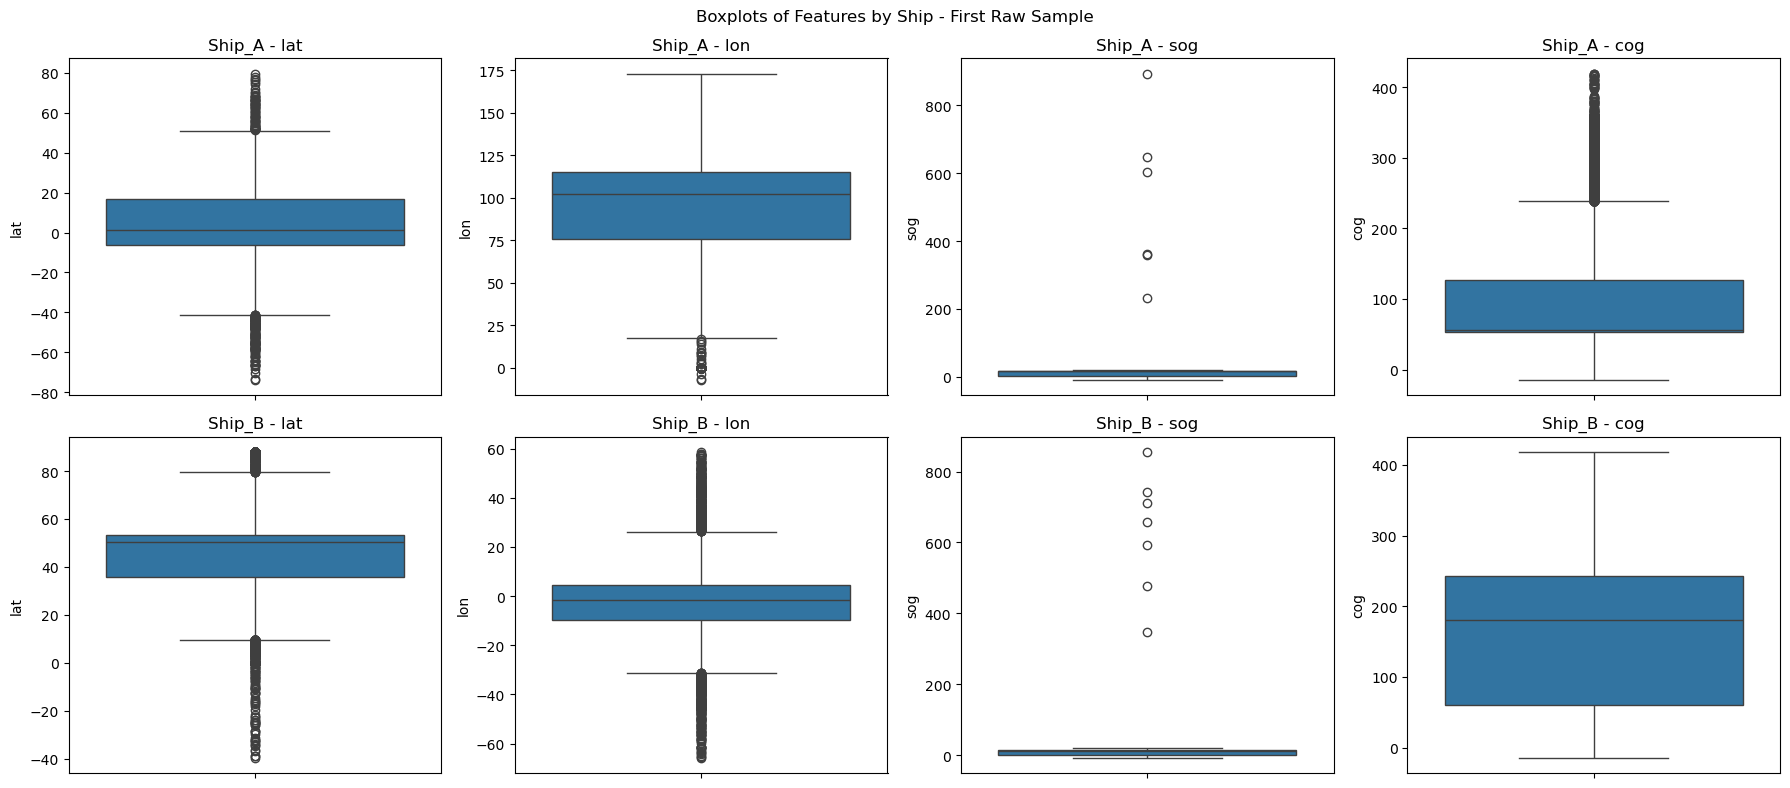

C:\Users\maorb\AppData\Local\Temp\ipykernel_42016\3006253437.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_odd_row"] = df[odd_flag_cols].fillna(False).any(axis=1)


,ship_name,time,lat,lon,sog,cog,lat_diff,lon_diff,sog_diff,cog_diff,time_diff_sec,lat_diff_abs_odd,lon_diff_abs_odd,sog_diff_abs_odd,cog_diff_abs_odd,time_diff_sec_odd
0,Ship_A,1.769600e+09,-28.927000,40.779099,18.299999,59.799999,0.016167,0.032700,0.099998,-2.100002,389.953,True,True,False,False,True
1,Ship_A,1.769600e+09,-28.904484,40.824665,18.400000,60.500000,0.018732,0.037998,0.100000,-0.200001,449.955,True,True,False,False,True
2,Ship_A,1.769600e+09,-28.897083,40.839817,18.500000,60.500000,0.007401,0.015152,0.100000,0.000000,179.985,False,True,False,False,False
3,Ship_A,1.769601e+09,-28.872150,40.891533,18.500000,61.200001,0.008467,0.018166,-0.200001,0.400002,209.947,False,True,False,False,True
4,Ship_A,1.769601e+09,-28.861633,40.914749,18.200001,63.200001,0.006950,0.015484,-0.199999,0.600002,179.994,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15665,Ship_B,1.771725e+09,4.130933,-12.564750,15.000000,143.000000,-0.028750,0.021084,-0.100000,0.000000,509.998,True,True,False,False,True
15666,Ship_B,1.771727e+09,-38.924213,-43.149906,14.900000,143.000000,-42.964729,-30.651588,0.000000,0.000000,120.002,True,True,False,False,False
15667,Ship_B,1.771727e+09,4.030433,-12.490933,14.900000,143.000000,42.954647,30.658974,0.000000,0.000000,60.000,True,True,False,False,False
15668,Ship_B,1.771727e+09,4.003767,-12.471367,14.900000,143.000000,-0.021717,0.015883,0.099999,0.000000,389.999,True,True,False,False,True


In [29]:
ships = ["Ship_A", "Ship_B"]
features = ["lat", "lon", "sog", "cog"]

plot_ship_boxplots(sample_raw, ships=ships, features=features, data_name="First Raw Sample")

odd_rows = find_consecutive_iqr_anomalies(sample_raw, ships=ships, features=features)
odd_rows

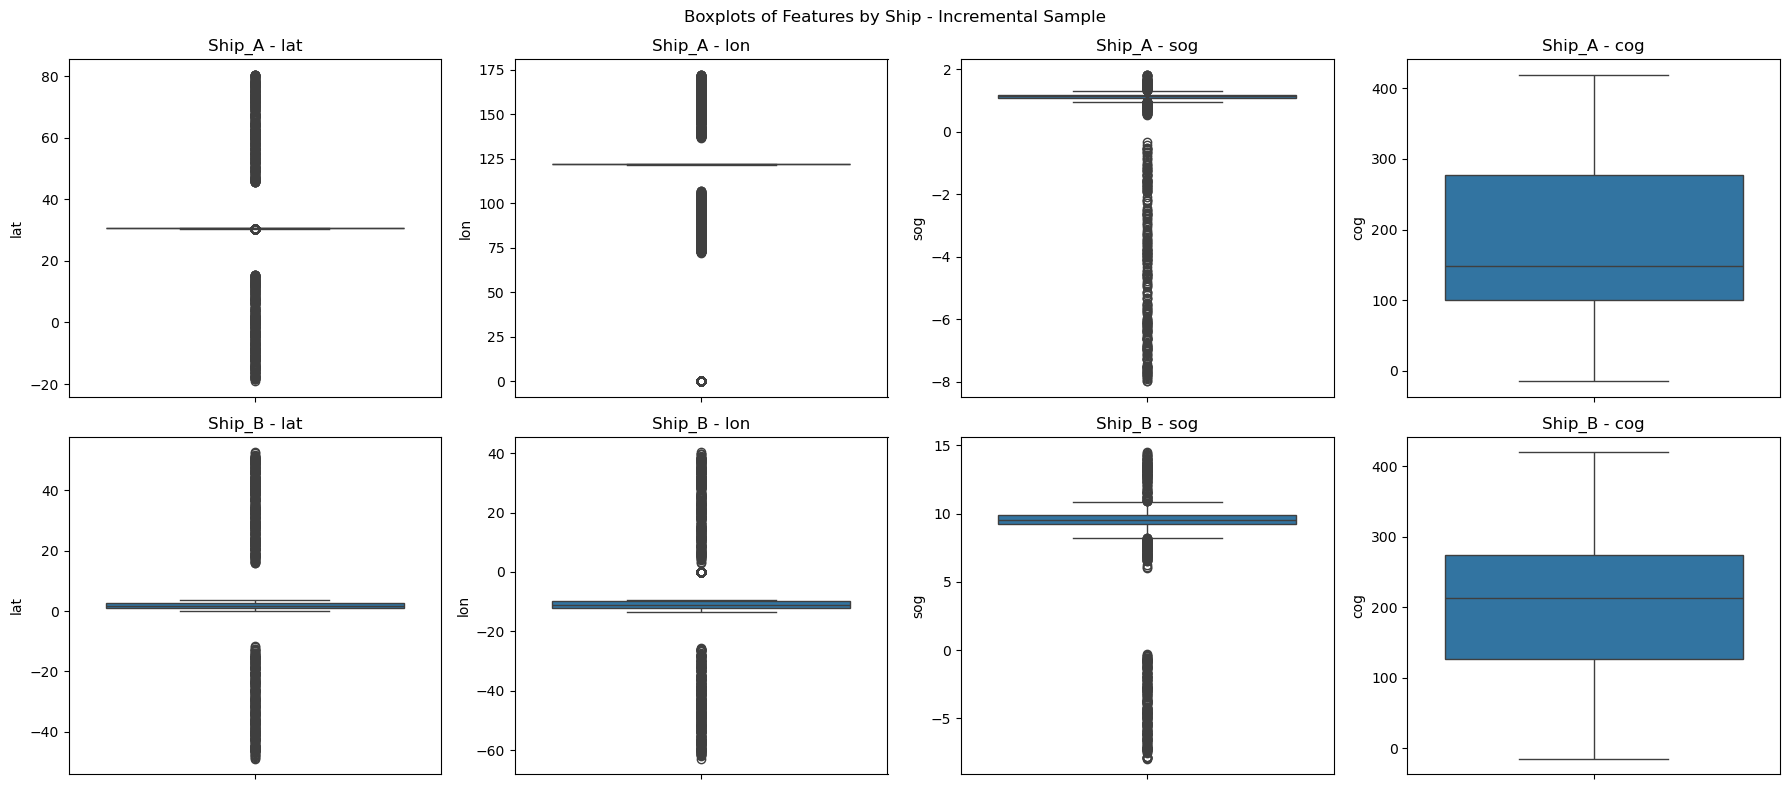

C:\Users\maorb\AppData\Local\Temp\ipykernel_42016\3006253437.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["is_odd_row"] = df[odd_flag_cols].fillna(False).any(axis=1)


,ship_name,time,lat,lon,sog,cog,lat_diff,lon_diff,sog_diff,cog_diff,time_diff_sec,lat_diff_abs_odd,lon_diff_abs_odd,sog_diff_abs_odd,cog_diff_abs_odd,time_diff_sec_odd
0,Ship_A,1.771731e+09,30.651337,122.026894,0.727895,265.320282,-0.000008,-0.000107,0.035099,-0.433899,30.006,False,False,False,False,True
1,Ship_A,1.771732e+09,30.651327,122.026772,0.690979,263.290955,-0.000010,-0.000122,-0.036916,-2.029327,30.013,False,False,False,False,True
2,Ship_A,1.771732e+09,30.651318,122.026665,0.756533,262.666382,-0.000010,-0.000107,0.065554,-0.624573,30.024,False,False,False,False,True
3,Ship_A,1.771732e+09,30.651304,122.026543,0.795649,260.439941,-0.000013,-0.000122,0.039116,-2.226440,30.028,False,False,False,False,True
4,Ship_A,1.771732e+09,30.651285,122.026413,0.719923,261.768494,-0.000019,-0.000130,-0.075726,1.328552,29.940,False,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4497,Ship_B,1.771920e+09,1.369906,-13.333209,9.286292,228.456894,-0.000854,-0.000964,14.957891,-0.176422,30.000,False,False,True,False,False
4498,Ship_B,1.771920e+09,1.366734,-13.337408,9.567537,415.726715,-0.000711,-0.001121,-0.026596,182.283905,30.000,False,False,False,True,False
4499,Ship_B,1.771920e+09,1.366046,-13.338527,9.474277,238.393814,-0.000688,-0.001119,-0.093260,-177.332901,30.000,False,False,False,True,False
4500,Ship_B,1.771920e+09,1.360234,-13.348918,-5.810600,242.515442,-0.000612,-0.001178,-15.531214,-0.776031,30.000,False,False,True,False,False


In [31]:
ships = ["Ship_A", "Ship_B"]
features = ["lat", "lon", "sog", "cog"]

plot_ship_boxplots(sample_incremental, ships=ships, features=features, data_name="Incremental Sample")

odd_rows = find_consecutive_iqr_anomalies(sample_incremental, ships=ships, features=features)
odd_rows